## Exploratory Data Analysis (EDA)

This notebook explores the cleaned dataset to understand
class imbalance, feature distributions, and early risk patterns.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/Credit_Risk_Project/data/cleaned_data.csv"
df = pd.read_csv(path)

df.shape, df.head()

((30000, 25),
    ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
 0   1      20000    2          2         1   24      2      2     -1     -1   
 1   2     120000    2          2         2   26     -1      2      0      0   
 2   3      90000    2          2         2   34      0      0      0      0   
 3   4      50000    2          2         1   37      0      0      0      0   
 4   5      50000    1          2         1   57     -1      0     -1      0   
 
    ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
 0  ...          0          0          0         0       689         0   
 1  ...       3272       3455       3261         0      1000      1000   
 2  ...      14331      14948      15549      1518      1500      1000   
 3  ...      28314      28959      29547      2000      2019      1200   
 4  ...      20940      19146      19131      2000     36681     10000   
 
    PAY_AMT4  PAY_AMT5  PAY_AMT6  default  
 0         0  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Target Variable Distribution

Understanding the default rate is critical for evaluating class imbalance
and guiding model validation strategies.


In [ ]:
df['default'].value_counts(normalize=True)


,proportion
default,
0,0.7788
1,0.2212


# Class Distribution
The dataset is imbalanced, with a minority of customers defaulting. This reflects real-world credit risk data and reinforces the need for early-warning signals rather than reactive prediction.

# Monthly Behavioral Features
The dataset contains six months of historical behavior for each customer:

PAY_0 to PAY_6: repayment status

BILL_AMT1 to BILL_AMT6: monthly bill amounts

PAY_AMT1 to PAY_AMT6: monthly payments

These columns are ordered in time, enabling analysis of trends and behavioral deterioration.

In [ ]:
pay_cols = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_0']
df[pay_cols].describe()

,PAY_6,PAY_5,PAY_4,PAY_3,PAY_2,PAY_0
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,-0.291100,-0.266200,-0.220667,-0.166200,-0.133767,-0.016700
std,1.149988,1.133187,1.169139,1.196868,1.197186,1.123802
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


### Payment Behavior Features

Features are engineered to capture trends and variability
in customer payment delays.


### Feature Engineering

This section creates derived behavioral and financial features
that will be used as inputs for downstream credit risk models.


In [ ]:
time_index = np.arange(len(pay_cols))

def compute_trend(row):
    return np.polyfit(time_index, row.values, 1)[0]

df['pay_delay_trend'] = df[pay_cols].apply(compute_trend, axis=1)

df.groupby('default')['pay_delay_trend'].mean()

,pay_delay_trend
default,
0,0.036403
1,0.107401


In [ ]:
df['pay_delay_volatility'] = df[pay_cols].std(axis=1)
df.groupby('default')['pay_delay_volatility'].mean()

,pay_delay_volatility
default,
0,0.385845
1,0.695435


In [ ]:
df['pay_trend'] = df['PAY_0'] - df['PAY_6']
df.groupby('default')['pay_trend'].mean()

,pay_trend
default,
0,0.194402
1,0.556058


In [ ]:
weights = np.array([1, 1.5, 2, 2.5, 3, 4])

df['recency_weighted_stress'] = (df[pay_cols] * weights).sum(axis=1)

df.groupby('default')['recency_weighted_stress'].mean()

,recency_weighted_stress
default,
0,-4.242403
1,5.825723


### Financial Stress Indicators

Bill-to-payment ratios are computed to measure repayment capacity.


In [ ]:
bill_cols = ['BILL_AMT6','BILL_AMT5','BILL_AMT4','BILL_AMT3','BILL_AMT2','BILL_AMT1']
pay_amt_cols = ['PAY_AMT6','PAY_AMT5','PAY_AMT4','PAY_AMT3','PAY_AMT2','PAY_AMT1']

df['bill_payment_ratio'] = (
    df[bill_cols].mean(axis=1) / (df[pay_amt_cols].mean(axis=1) + 1)
)

df.groupby('default')['bill_payment_ratio'].mean()

,bill_payment_ratio
default,
0,81.880925
1,221.778078


In [ ]:
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
limit = df['LIMIT_BAL']

df['avg_utilization'] = df[bill_cols].mean(axis=1) / limit
df.groupby('default')['avg_utilization'].mean()

,avg_utilization
default,
0,0.351391
1,0.449298


In [ ]:
df[['pay_delay_trend',
    'pay_delay_volatility',
    'recency_weighted_stress',
    'bill_payment_ratio']].describe()

,pay_delay_trend,pay_delay_volatility,recency_weighted_stress,bill_payment_ratio
count,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,5.210762e-02,0.454326,-2.015333,112.826175
std,2.271455e-01,0.516221,13.734765,2930.690927
min,-1.542857e+00,0.000000,-28.000000,-6467.833333
25%,-1.590241e-17,0.000000,-11.500000,1.390802
50%,0.000000e+00,0.408248,0.000000,9.386733
75%,1.428571e-01,0.836660,0.000000,23.154315
max,1.285714e+00,3.204164,87.000000,361977.666667


These features are continuous, interpretable, and capture temporal deterioration, instability, recency effects, and liquidity stress.

### Feature Distribution Analysis

Key numerical and categorical features are analyzed to identify
skewness, outliers, and risk-related trends.


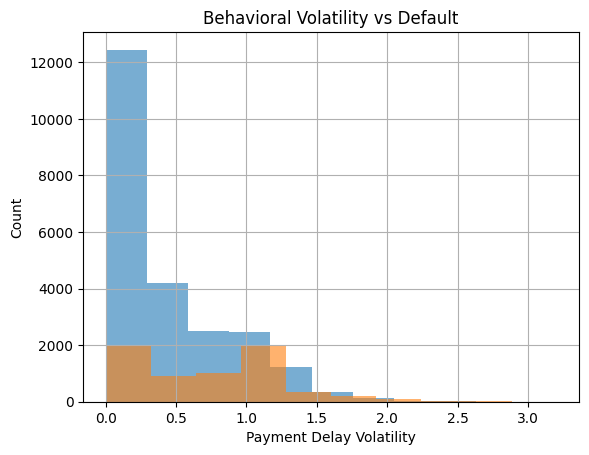

In [ ]:
plt.figure()
df[df['default']==0]['pay_delay_volatility'].hist(alpha=0.6)
df[df['default']==1]['pay_delay_volatility'].hist(alpha=0.6)
plt.xlabel("Payment Delay Volatility")
plt.ylabel("Count")
plt.title("Behavioral Volatility vs Default")
plt.show()

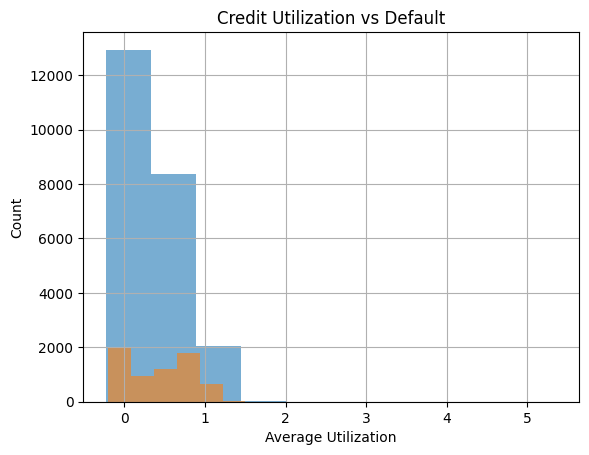

In [ ]:
plt.figure()
df[df['default']==0]['avg_utilization'].hist(alpha=0.6)
df[df['default']==1]['avg_utilization'].hist(alpha=0.6)
plt.xlabel("Average Utilization")
plt.ylabel("Count")
plt.title("Credit Utilization vs Default")
plt.show()

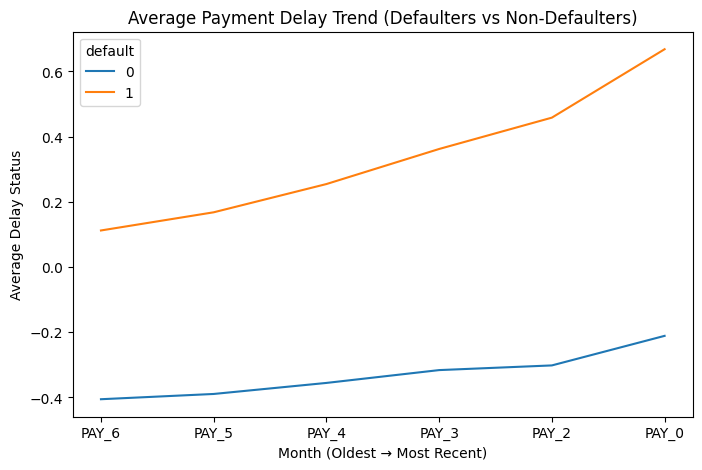

In [ ]:
df.groupby('default')[pay_cols].mean().T.plot(figsize=(8,5))
plt.title("Average Payment Delay Trend (Defaulters vs Non-Defaulters)")
plt.xlabel("Month (Oldest → Most Recent)")
plt.ylabel("Average Delay Status")
plt.show()

# Insight
ustomers who eventually default show a clear worsening trend in repayment behavior, especially in recent months. This supports the hypothesis that default is preceded by observable behavioral deterioration.

In [ ]:
bill_cols = ['BILL_AMT6','BILL_AMT5','BILL_AMT4','BILL_AMT3','BILL_AMT2','BILL_AMT1']
pay_amt_cols = ['PAY_AMT6','PAY_AMT5','PAY_AMT4','PAY_AMT3','PAY_AMT2','PAY_AMT1']


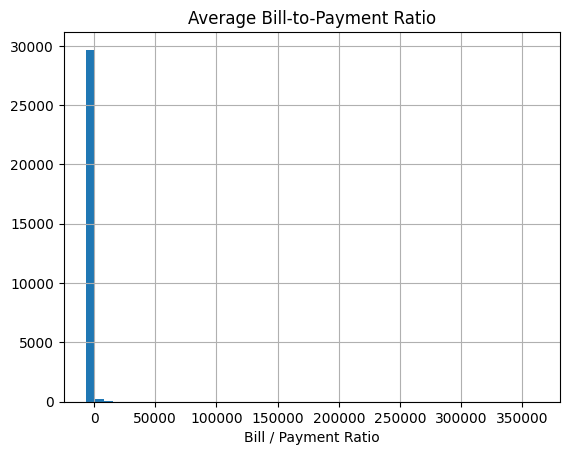

In [ ]:
(df[bill_cols].mean(axis=1) / (df[pay_amt_cols].mean(axis=1) + 1)).hist(bins=50)
plt.title("Average Bill-to-Payment Ratio")
plt.xlabel("Bill / Payment Ratio")
plt.show()


# Insight
A high bill-to-payment ratio indicates financial strain, where customers consistently pay less relative to billed amounts. This ratio serves as an interpretable proxy for liquidity stress.

# Temporal Observations

Recent behavior is more predictive than older behavior

Default is preceded by gradual deterioration, not sudden collapse

Stability and volatility across months provide early-warning signals

These observations motivate the creation of trend-based and recency-weighted features in the modeling phase.

In [ ]:
save_path = "/content/drive/MyDrive/Credit_Risk_Project/data/behavioral_features.csv"
df.to_csv(save_path, index=False)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/Credit_Risk_Project/data/behavioral_features.csv


EDA insights guide feature engineering decisions in the next notebook.
